<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/11%EC%A3%BC%EC%B0%A8/data_preprocessing_visualization_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **자료 전처리(Data Preprocessin) 및 시각화 (Data Visualization)**

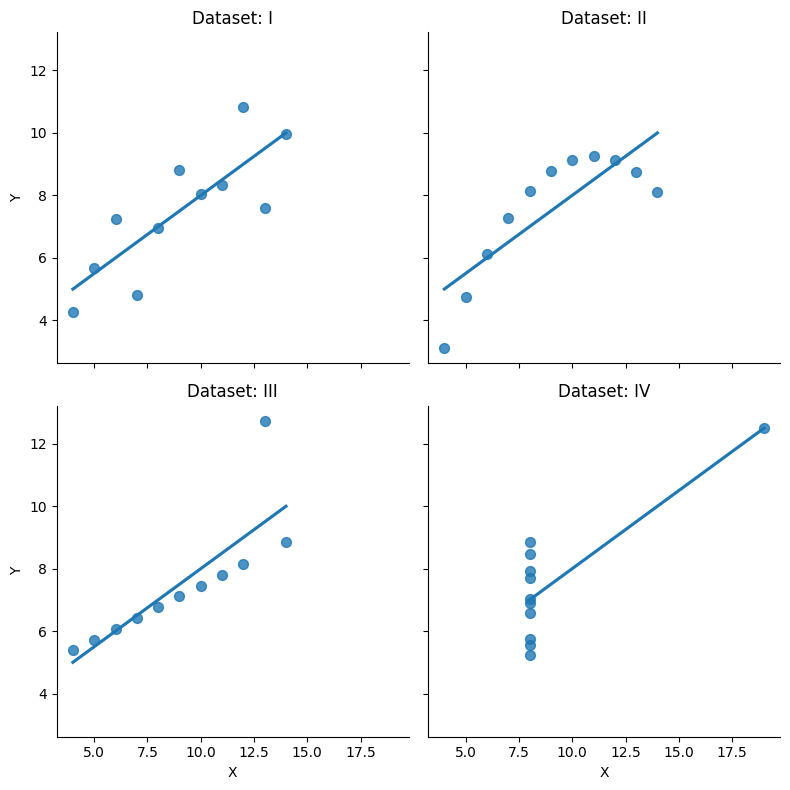

In [3]:
# prompts: content/sample_data/anscombe.json 을 데이터프레임으로 읽고 각 Series별로 scatter와 회귀식을 2 by 2 로 시각화해줘

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the dataset
anscombe_df = pd.read_json('/content/sample_data/anscombe.json')

# Create a FacetGrid with 'Series' as the column and plot scatter plots
g = sns.FacetGrid(anscombe_df, col='Series', col_wrap=2, height=4)
g.map(sns.regplot, 'X', 'Y', ci=None, scatter_kws={'s': 50})

# Set titles for each subplot
for ax, title in zip(g.axes.flat, anscombe_df['Series'].unique()):
    ax.set_title(f'Dataset: {title}')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# **기술통계 분석**
## **1. 모집단 데이터 수집**
- [공공데이터 다운받기](https://data.seoul.go.kr/dataList/OA-15246/F/1/datasetView.do#)
- **서울시 공공자전거 이용정보(일별) 서울특별시 공공자전거 이용정보(일별)_2412.csv 파일**

In [10]:
import pandas as pd

# Load the CSV file into a DataFrame
# Use engine='python' and on_bad_lines='skip' to handle potential parsing issues and skip bad lines
bike_df = pd.read_csv('/content/서울특별시 공공자전거 이용정보(일별)_2412 (1).csv', encoding='cp949', engine='python', on_bad_lines='skip')

# Display the first few rows of the DataFrame
display(bike_df.head())

,대여일자,대여소번호,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2024-12-01,737,737. 장수공원,정기권,NaN,~10대,1,20.97,0.18,790.32,14
1,2024-12-01,1153,"1153. 발산역 1번, 9번 인근 대여소",정기권,NaN,~10대,1,NaN,NaN,1143.00,56
2,2024-12-01,1155,1155. 기쁜우리복지관,정기권,NaN,~10대,1,12.49,0.15,643.66,4
3,2024-12-01,1442,1442. 중랑구청 중화동 별관 앞,정기권,NaN,~10대,3,217.31,1.43,6152.66,42
4,2024-12-01,1160,1160. 양천향교역 7번출구앞,정기권,NaN,~10대,1,28.23,0.30,1296.07,8


In [12]:
bike_df.shape

(1410916, 11)

## **2. 표본 무작위 추출(random sampling)**

In [55]:
df = bike_df.sample(n=1000, random_state=42)
df

,대여일자,대여소번호,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
236013,2024-12-05,442,442.서울역 서부,일일권,F,30대,1,15.96,0.14,620.00,5
404498,2024-12-09,660,660. 동의보감타워,정기권,F,50대,1,12.17,0.15,640.00,7
599230,2024-12-12,398,398. 을지로3가역 3번출구,정기권,M,20대,1,26.55,0.22,957.67,5
759406,2024-12-16,143,143. 공덕역 2번출구,정기권,M,40대,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226,1226. 잠실4동 주민센터 옆,정기권,F,30대,3,50.63,0.52,2268.26,24
...,...,...,...,...,...,...,...,...,...,...,...
609898,2024-12-13,1149,1149. 신방화역환승주차장,정기권,NaN,20대,5,116.24,1.26,5361.60,49
1167506,2024-12-26,2622,2622. 올림픽공원역 3번출구,정기권,NaN,40대,1,40.58,0.34,1463.80,10
221596,2024-12-05,2718,2718.마곡수명산파크1단지,정기권,F,기타,1,14.98,0.15,630.40,4
221279,2024-12-05,1135,1135. 강서구의회,정기권,F,60대,1,41.32,0.37,1605.09,8


In [56]:
# Calculate and display gender distribution for the original bike_df
print("Gender distribution in original bike_df:")
display(bike_df['성별'].value_counts(normalize=True).dropna())

# Calculate and display gender distribution for the simple random sample df
print("\nGender distribution in simple random sample df:")
display(df['성별'].value_counts(normalize=True).dropna())

Gender distribution in original bike_df:


,proportion
성별,
M,0.639418
F,0.360374
m,0.000127
f,0.000082



Gender distribution in simple random sample df:


,proportion
성별,
M,0.627717
F,0.372283


## 3. 데이터 전처리

In [69]:
# prompt: df의 컬럼의 자료형태, 고유값, 결측치, 결측치비율, 최빈값 10개 보여주는 데이터프레임을 생성하는 함수

# Create an empty list to store the results for each column

def summary(dataframe):
    column_info_list = []

    # Iterate through each column in the DataFrame
    for col in dataframe.columns:
        # Get the data type
        dtype = dataframe[col].dtype

        # Calculate unique values count
        unique_count = dataframe[col].nunique()

        # Calculate missing values count
        missing_count = dataframe[col].isnull().sum()

        # Calculate missing values ratio
        missing_ratio = missing_count / len(dataframe) * 100

        # Calculate the top 10 most frequent values (mode)
        # Handle cases where there are fewer than 10 unique values or all values are unique
        top_modes = dataframe[col].value_counts().nlargest(10).index.tolist()

        # Append the results to the list
        column_info_list.append({
            '컬럼명': col,
            '자료형태': dtype,
            '고유값 수': unique_count,
            '결측치 수': missing_count,
            '결측치 비율 (%)': round(missing_ratio, 2),
            '최빈값 (Top 10)': top_modes
        })

    # Create a DataFrame from the list of column information
    column_info_df_with_dtype = pd.DataFrame(column_info_list)
    column_info_df_with_dtype = column_info_df_with_dtype.set_index('컬럼명')
    return column_info_df_with_dtype

# Display the resulting DataFrame
summary(df)

,자료형태,고유값 수,결측치 수,결측치 비율 (%),최빈값 (Top 10)
컬럼명,,,,,
대여일자,datetime64[ns],31,0,0.0,"[2024-12-07 00:00:00, 2024-12-10 00:00:00, 202..."
대여소,object,790,0,0.0,"[5333. 노원역9번-10번 출구 앞, 703. 오목교역 7번출구 앞, 1184...."
대여구분코드,object,3,0,0.0,"[정기권, 일일권, 일일권(비회원)]"
성별,object,2,264,26.4,"[M, F]"
연령대,float64,7,93,9.3,"[20.0, 30.0, 40.0, 50.0, 10.0, 60.0, 70.0]"
이용건수,int64,11,0,0.0,"[1, 2, 3, 4, 5, 6, 9, 8, 7, 11]"
운동량,float64,929,4,0.4,"[0.0, 26.46, 22.65, 26.39, 14.54, 21.93, 15.7,..."
탄소량,float64,215,4,0.4,"[0.0, 0.32, 0.19, 0.22, 0.15, 0.16, 0.21, 0.38..."
이동거리(M),float64,934,0,0.0,"[0.0, 790.0, 830.0, 980.0, 640.0, 850.0, 1090...."


## 3.1. 대여소번호 컬럼은 삭제해줘

In [58]:
# Drop the '대여소번호' column
df = df.drop('대여소번호', axis=1)

# Display the first few rows of the DataFrame after dropping the column
display(df.head())

,대여일자,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
236013,2024-12-05,442.서울역 서부,일일권,F,30대,1,15.96,0.14,620.00,5
404498,2024-12-09,660. 동의보감타워,정기권,F,50대,1,12.17,0.15,640.00,7
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20대,1,26.55,0.22,957.67,5
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40대,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30대,3,50.63,0.52,2268.26,24


## 3.2. 대여일자를 날짜형태로 변경해줘

In [59]:
# Convert '대여일자' column to datetime objects
df['대여일자'] = pd.to_datetime(df['대여일자'])

# Verify the data type after conversion
print("Data types after converting '대여일자' to datetime:")
display(df.info())

Data types after converting '대여일자' to datetime:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 236013 to 351352
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   대여일자     1000 non-null   datetime64[ns]
 1   대여소      1000 non-null   object        
 2   대여구분코드   1000 non-null   object        
 3   성별       736 non-null    object        
 4   연령대      1000 non-null   object        
 5    이용건수    1000 non-null   int64         
 6   운동량      996 non-null    float64       
 7   탄소량      996 non-null    float64       
 8   이동거리(M)  1000 non-null   float64       
 9   이용시간(분)  1000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 118.2+ KB


None

In [60]:
df.head()

,대여일자,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
236013,2024-12-05,442.서울역 서부,일일권,F,30대,1,15.96,0.14,620.00,5
404498,2024-12-09,660. 동의보감타워,정기권,F,50대,1,12.17,0.15,640.00,7
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20대,1,26.55,0.22,957.67,5
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40대,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30대,3,50.63,0.52,2268.26,24


## 3.3. 연령대 컬럼의 값에서 수자만 추출

In [61]:
import re

# Function to extract numbers from the '연령대' string
def extract_age(age_str):
    if pd.isna(age_str):
        return None
    age_str = str(age_str) # Ensure it's a string
    if '~10대' in age_str:
        return 10
    elif '70대이상' in age_str:
        return 70
    elif '기타' in age_str:
        return None # Or some other indicator for '기타'
    else:
        # Find all digits in the string
        numbers = re.findall(r'\d+', age_str)
        if numbers:
            return int(numbers[0]) # Return the first number found
        else:
            return None # Return None if no number is found

# Apply the function to the '연령대' column and create a new column or overwrite the existing one
# Here we overwrite the existing '연령대' column
df['연령대'] = df['연령대'].apply(extract_age)

# Display the first few rows with the modified '연령대' column
display(df.head())

# Display the unique values in the modified '연령대' column to verify
print("\nUnique values in the modified '연령대' column:")
display(df['연령대'].unique())

,대여일자,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
236013,2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5
404498,2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24



Unique values in the modified '연령대' column:


array([30., 50., 20., 40., nan, 60., 10., 70.])

### 3.4. 모든 결측를 제거

In [62]:
# Drop all rows with any missing values
df_cleaned = df.dropna()

# Display the shape of the original and cleaned DataFrames to see how many rows were dropped
print("Original DataFrame shape:", df.shape)
print("Cleaned DataFrame shape (rows with missing values dropped):", df_cleaned.shape)

# Optionally, display the head of the cleaned DataFrame
# display(df_cleaned.head())

Original DataFrame shape: (1000, 10)
Cleaned DataFrame shape (rows with missing values dropped): (670, 10)


In [63]:
df_cleaned

,대여일자,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
236013,2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5
404498,2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24
...,...,...,...,...,...,...,...,...,...,...
1183410,2024-12-26,2104. 사당역 5번출구,정기권,M,40.0,1,167.66,1.28,5498.46,39
174230,2024-12-04,3523. 건국대학교 과학관(이과대) 앞,정기권,M,40.0,1,64.33,0.48,2056.31,12
808455,2024-12-17,5333. 노원역9번-10번 출구 앞,정기권,M,40.0,1,75.91,0.49,2130.00,16
221279,2024-12-05,1135. 강서구의회,정기권,F,60.0,1,41.32,0.37,1605.09,8


In [64]:
df_cleaned.columns

Index(['대여일자', '대여소', '대여구분코드', '성별', '연령대', ' 이용건수', '운동량', '탄소량', '이동거리(M)',
       '이용시간(분)'],
      dtype='object')

In [65]:
# ['대여일자', '대여소', '대여구분코드', '성별', '연령대', ' 이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)'] 를 영어와 mapping한 사전형 자료
# Create a dictionary mapping Korean column names to English equivalents
column_name_mapping = {
    '대여일자': 'Rental_Date',
    '대여소': 'Rental_Station',
    '대여구분코드': 'Rental_Type_Code',
    '성별': 'Gender',
    '연령대': 'Age_Group',
    ' 이용건수': 'Rental_Count',
    '운동량': 'Exercise_Amount',
    '탄소량': 'Carbon_Amount',
    '이동거리(M)': 'Distance_M',
    '이용시간(분)': 'Duration_Minutes'
}

# Display the dictionary
display(column_name_mapping)

{'대여일자': 'Rental_Date',
 '대여소': 'Rental_Station',
 '대여구분코드': 'Rental_Type_Code',
 '성별': 'Gender',
 '연령대': 'Age_Group',
 ' 이용건수': 'Rental_Count',
 '운동량': 'Exercise_Amount',
 '탄소량': 'Carbon_Amount',
 '이동거리(M)': 'Distance_M',
 '이용시간(분)': 'Duration_Minutes'}

In [66]:
# Rename columns using the mapping dictionary
df_cleaned = df_cleaned.rename(columns=column_name_mapping)

# Display the first few rows of the DataFrame with renamed columns
display(df_cleaned.head())

,Rental_Date,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes
236013,2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5
404498,2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24


In [84]:
df_cleaned['Rental_Date'].dt.day_name().head()

,Rental_Date
236013,Thursday
404498,Monday
599230,Thursday
759406,Monday
218405,Thursday


In [87]:
df_cleaned['days'] = df_cleaned['Rental_Date'].dt.day_name()
df_cleaned.head()

,Rental_Date,Rental_Station,Rental_Type_Code,Gender,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes,days
236013,2024-12-05,442.서울역 서부,일일권,F,30.0,1,15.96,0.14,620.00,5,Thursday
404498,2024-12-09,660. 동의보감타워,정기권,F,50.0,1,12.17,0.15,640.00,7,Monday
599230,2024-12-12,398. 을지로3가역 3번출구,정기권,M,20.0,1,26.55,0.22,957.67,5,Thursday
759406,2024-12-16,143. 공덕역 2번출구,정기권,M,40.0,1,31.81,0.25,1071.04,9,Monday
218405,2024-12-05,1226. 잠실4동 주민센터 옆,정기권,F,30.0,3,50.63,0.52,2268.26,24,Thursday


In [89]:
## Rental_Type_Code의 비회원권은 결측치를 제거하면서 삭제됨
summary(df_cleaned)

,자료형태,고유값 수,결측치 수,결측치 비율 (%),최빈값 (Top 10)
컬럼명,,,,,
Rental_Date,datetime64[ns],31,0,0.0,"[2024-12-10 00:00:00, 2024-12-07 00:00:00, 202..."
Rental_Station,object,565,0,0.0,"[5333. 노원역9번-10번 출구 앞, 703. 오목교역 7번출구 앞, 2619...."
Rental_Type_Code,object,2,0,0.0,"[정기권, 일일권]"
Gender,object,2,0,0.0,"[M, F]"
Age_Group,float64,7,0,0.0,"[20.0, 30.0, 40.0, 50.0, 10.0, 60.0, 70.0]"
Rental_Count,int64,11,0,0.0,"[1, 2, 3, 4, 5, 6, 9, 8, 11, 16]"
Exercise_Amount,float64,633,0,0.0,"[0.0, 28.04, 21.93, 19.79, 10.67, 22.65, 77.96..."
Carbon_Amount,float64,203,0,0.0,"[0.0, 0.32, 0.22, 0.19, 0.15, 0.2, 0.18, 0.24,..."
Distance_M,float64,634,0,0.0,"[0.0, 850.0, 1480.0, 650.0, 620.0, 640.0, 1090..."


# 4. 기초 통계 분석

In [90]:
df_cleaned.describe()

,Rental_Date,Age_Group,Rental_Count,Exercise_Amount,Carbon_Amount,Distance_M,Duration_Minutes
count,670,670.000000,670.000000,670.000000,670.000000,670.000000,670.000000
mean,2024-12-15 17:22:23.283582208,32.970149,1.634328,85.804104,0.731463,3152.788164,29.108955
min,2024-12-01 00:00:00,10.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2024-12-09 00:00:00,20.000000,1.000000,25.545000,0.220000,960.635000,7.000000
50%,2024-12-15 00:00:00,30.000000,1.000000,50.700000,0.445000,1915.665000,15.000000
75%,2024-12-23 00:00:00,40.000000,2.000000,97.122500,0.850000,3676.127500,38.000000
max,2024-12-31 00:00:00,70.000000,16.000000,707.300000,6.320000,27233.540000,395.000000
std,NaN,14.650355,1.412844,102.461658,0.850553,3664.138509,38.800418


# **데이터분석 작업은 중간 중간에 매듭을(Divide-and-conquer)**
## **데이터전체 작업을 분절하여 Pipeline으로 연결하라(Data Pilpeline)**

In [91]:
#  나의 드라이브를 마운트 해줘
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [92]:
# /content/drive/MyDrive/데이터분석입문 에 data 폴더를 만들고  해당 폴더에 df_cleaned를 pickle 형태로 저장해줘

import os

# Define the path to the data directory in Google Drive
drive_data_path = '/content/drive/MyDrive/데이터분석입문/data'

# Create the directory if it doesn't exist
if not os.path.exists(drive_data_path):
    os.makedirs(drive_data_path)
    print(f"Directory '{drive_data_path}' created.")
else:
    print(f"Directory '{drive_data_path}' already exists.")

# Define the full path for the pickle file
pickle_file_path = os.path.join(drive_data_path, 'df_cleaned.pkl')

# Save the df_cleaned DataFrame to the specified path in pickle format
df_cleaned.to_pickle(pickle_file_path)

print(f"DataFrame 'df_cleaned' saved to '{pickle_file_path}' in pickle format.")

Directory '/content/drive/MyDrive/데이터분석입문/data' created.
DataFrame 'df_cleaned' saved to '/content/drive/MyDrive/데이터분석입문/data/df_cleaned.pkl' in pickle format.
